## Assignment 3: $k$ Nearest Neighbor


**Q1.**
1. What is the difference between regression and classification?
2. What is a confusion table? What does it help us understand about a model's performance?
3. What does the SSE quantify about a particular model?
4. What are overfitting and underfitting?
5. Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or SSE on the test set, improve model performance?
6. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.

**Q2.** This is a case study on $k$ nearest neighbor classification, using the `land_mines.csv` data.

The data consists of a label, `mine_type`, taking integer values 1 to 5, and three properties of the mine, `voltage`, `height` and `soil`. We want to predict the kind of mine from data about it. Imagine working for the DOD or a humanitarian aid agency, trying to help people remove land mines more safely.

1. Load the data. Perform some EDA, summarizing the target label and the features.
2. Split the sample 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be, in my experience: Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Build a $k$-NN classifier. Explain how you select $k$.
4. Print a confusion table for the optimal model, comparing predicted and actual class label on the test set. How accurate is it? Where is performance more or less accurate?
5. Notice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. Please explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make.

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Becca Hobson

**Date:** 9/30/2026

In [1]:
# Your Phase 1 solution to the problem goes here.

1. Regression predicts a numerical value while classification predicts a categorical value.
2. A confusion table compares a classification model's predictions against the actual labels from a dataset. This is useful because instead of describing how often a model is right or wrong, it provides the details of how and where the model is making mistakes.
3. The sum of squared errors (SSE) quantifies the difference between the actual values in the data set and the values predicted by the model.
4. Overfitting is the result of a k value that is too small, and results in a model that overfits noise and performs poorly due to excess complexity in the training. Underfitting is the result of a k value that is too large, and resutls in a model that perofrms poorly due to making assumptions and giving too similar of predictions for each dat point.
5. Splittign the data is necessary to ensure the model has actually learned how to predict data, and didn't just memorized every value. Choosing  k  by evaluating accuracy or SSE on the test set improves the model performace signifgantly by optimizing k to avoid both overfitting and underfitting.
6. A class label is simple and easy to interpret because it gives one clear prediction, however, it doesn’t describe how confident the model is. A probability distribution gives more information by showing how likely each class is, but it can be more complicated to interpret and still requires choosing a class if you need one final prediction.

voltage      0
height       0
soil         0
mine_type    0
dtype: int64


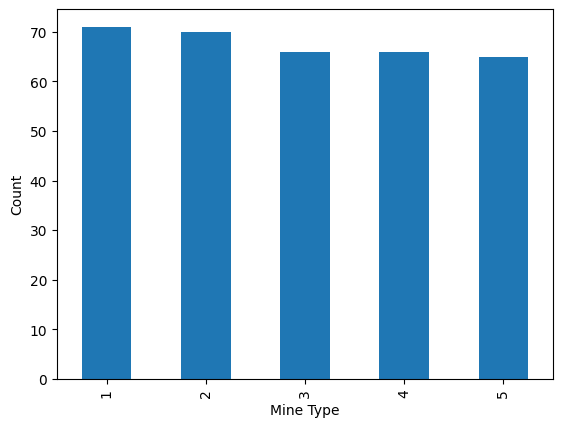

Training set size: 169
Test set size: 169

Training mine types:
mine_type
1    35
2    35
3    33
4    33
5    33
Name: count, dtype: int64

Test mine types:
mine_type
1    36
2    35
3    33
4    33
5    32
Name: count, dtype: int64

Optimal k: 1
Validation accuracy: 0.46153846153846156


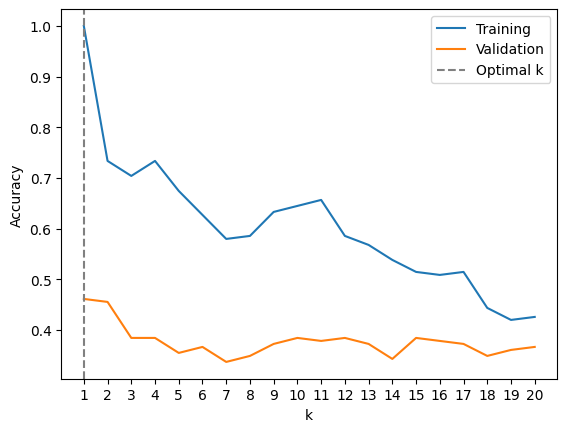

Predicted   1   2  3   4  5
Actual                     
1          21   0  4   4  7
2           0  32  0   3  0
3           8   0  7  10  8
4           7   5  4  11  6
5           7   0  9   9  7

Accuracy: 0.46153846153846156


In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier

lmdf=pd.read_csv('/content/land_mines.csv')

#EDA
lmdf.sample(20) #inspecting dataset
lmdf.shape #target label: mine_type / features: voltage, height, soil
print(lmdf.isna().sum()) #no missing values present

lmdf['mine_type'].value_counts().sort_index() #realtively balnced distribution
lmdf['mine_type'].value_counts().sort_index().plot(kind='bar')
plt.xlabel('Mine Type')
plt.ylabel('Count')
plt.show()

lmdf[['voltage', 'height', 'soil']].describe()

#Split Sample 50/50
X = lmdf[['voltage', 'height', 'soil']] #separate features from target label
y = lmdf['mine_type']

X_train, X_test, y_train, y_test = train_test_split( #split data
    X,
    y,
    test_size=0.5,
    random_state=42,
    stratify=y)

print('Training set size:', len(X_train)) #check size of each set
print('Test set size:', len(X_test))
print('\nTraining mine types:') #check that mine types are represented in both sets
print(y_train.value_counts().sort_index())

print('\nTest mine types:')
print(y_test.value_counts().sort_index())

#kNN classifier
eval_scaler = MinMaxScaler() #scale the training and test data
X_train_scaled = eval_scaler.fit_transform(X_train)
X_test_scaled = eval_scaler.transform(X_test)

eval_ks = np.arange(1, 21) #compare k vlaues 1-20
eval_valid_accuracy = []
eval_train_accuracy = []

for eval_k in eval_ks: #build and fit a separate model for each k using training data
    eval_candidate = KNeighborsClassifier(n_neighbors=int(eval_k))
    eval_candidate.fit(X_train_scaled, y_train)

    eval_valid_hat = eval_candidate.predict(X_test_scaled)
    eval_train_hat = eval_candidate.predict(X_train_scaled)

    eval_valid_accuracy.append(
        np.mean(y_test.to_numpy() == eval_valid_hat))

    eval_train_accuracy.append(
        np.mean(y_train.to_numpy() == eval_train_hat))

eval_k_star = int(eval_ks[np.argmax(eval_valid_accuracy)]) #select best k

print('\nOptimal k:', eval_k_star)
print('Validation accuracy:', max(eval_valid_accuracy))

#compare training vs. validation accuracy to check for overfitting
plt.plot(eval_ks, eval_train_accuracy, label='Training') #plot accuracy for each k
plt.plot(eval_ks, eval_valid_accuracy, label='Validation')
plt.axvline(eval_k_star, linestyle='--', color='gray', label='Optimal k') #label chosen k as optimal
plt.xlabel('k')
plt.ylabel('Accuracy')
plt.xticks(eval_ks)
plt.legend()
plt.show()

#Confusion Tble & Optimal Model
optimal_model = KNeighborsClassifier(n_neighbors=eval_k_star)
optimal_model.fit(X_train_scaled, y_train)
y_pred = optimal_model.predict(X_test_scaled) #predict mine type

confusion_table = pd.crosstab( #create confusion table
    y_test,
    y_pred,
    rownames=['Actual'],
    colnames=['Predicted'])
print(confusion_table)

accuracy = np.mean(y_test.to_numpy() == y_pred) #calcualte overall accuracy
print('\nAccuracy:', accuracy)


1. EDA: The dataset has 338 observations with no missing values, and the five mine types are nearly balanced (65–71 each). The target label is mine type and the features are voltage, height, and soil. The three features are all on roughly a 0–1 scale.

2. Split 50/50: I split the data 50/50 so that each mine type appears in both halves in equal numbers (169 observations each). This prevents any class from missing entirely from the training or test set.

3. kNN Classifier: I scaled the features, fit a classifier on the training set for each k from 1 to 20, and compared accuracy on the test set. I selected the k with the highest test accuracy, which was k = 1 (46.2%).

4. Confusion Table: The optimal model is 46.2% accurate overall, well above the 20% expected from guessing among five balanced classes. Type 2 is the easiest to identify, type 1 is moderate, and types 3, 4 and 5 are less accurate and are mostly confused with each other.

5. Model Usage: The model should be used as a tool, not a final identification, since even its overall accuracy is under 50%. A "type 2" prediction can be trusted fairly well, but predictions of types 3, 4 or 5 are right less frequently and often confused, so those should be verified with additional checks.

## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** [To be provided]
- **AI tool and model used:** [To be provided]

### *Prompts used

1. [Paste prompt]
2. [Paste follow-up prompt]

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. ...
2. ...

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept / modify / reject | ... |
| 2 | Accept / modify / reject | ... |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [ ]:
# Your Phase 2 solution to the problem goes here.


### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]